# Graph operations

This notebook shows common editing and transformation operations for `UrbanGraph` objects.


In [1]:
# To install IduEdu in a clean environment:
# !pip install IduEdu

OSM_ID = 1114252


In [2]:
from iduedu import get_walk_graph

G = get_walk_graph(osm_id=OSM_ID, simplify=False, keep_largest_subgraph=True)
print(G)


2026-07-07 15:18:10.561 | WARNING  | Removing 618 nodes outside the largest connected component. Retaining 38246 of 38864 nodes.


UrbanGraph(nodes=38246, edges=45042, is_multigraph=True, is_directed=False, edge_direction_column=None, crs='EPSG:32636', type='walk')


## Induced subgraph and relabeling

`subgraph_by_nodes` preserves original node ids. `relabel` converts them to a dense `RangeIndex`.


In [3]:
nodes = G.nodes_gdf.index[:150]
subgraph = G.subgraph_by_nodes(nodes)
relabeled = subgraph.relabel()

print("subgraph index sample:", list(subgraph.nodes_gdf.index[:5]))
print("relabeled index sample:", list(relabeled.nodes_gdf.index[:5]))
print(subgraph)
print(relabeled)


subgraph index sample: [0, 1, 2, 3, 4]
relabeled index sample: [0, 1, 2, 3, 4]
UrbanGraph(nodes=150, edges=146, is_multigraph=True, is_directed=False, edge_direction_column=None, crs='EPSG:32636', type='walk')
UrbanGraph(nodes=150, edges=146, is_multigraph=True, is_directed=False, edge_direction_column=None, crs='EPSG:32636', type='walk')


## Clip by geometry

`clip` keeps nodes inside a polygon and then keeps edges whose endpoints remain in the graph. The polygon must be in the graph CRS.


In [4]:
center = G.nodes_gdf.geometry.iloc[0]
clip_polygon = center.buffer(700)
clipped = G.clip(clip_polygon).relabel()

print("before:", len(G.nodes_gdf), "nodes,", len(G.edges_gdf), "edges")
print("after :", len(clipped.nodes_gdf), "nodes,", len(clipped.edges_gdf), "edges")


before: 38246 nodes, 45042 edges
after : 5365 nodes, 6459 edges


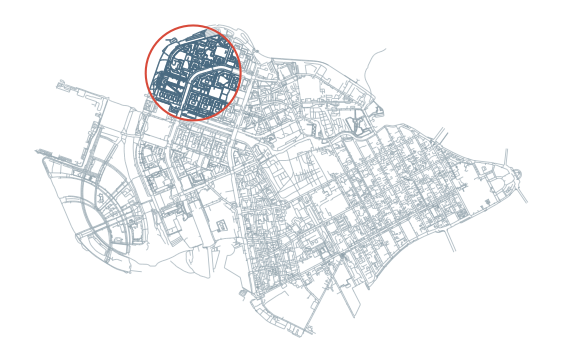

In [5]:
import geopandas as gpd
import matplotlib.pyplot as plt

clip_boundary = gpd.GeoSeries([clip_polygon], crs=G.crs)
fig, ax = plt.subplots(figsize=(7, 7))
G.edges_gdf.plot(ax=ax, color="#8FA1AB", linewidth=0.65, alpha=0.65)
clipped.edges_gdf.plot(ax=ax, color="#496A81", linewidth=1.0, alpha=0.9)
clip_boundary.boundary.plot(ax=ax, color="#D84A3A", linewidth=1.5)
ax.set_axis_off()
plt.show()


## Multiedge simplification

`simplify_multiedges` collapses parallel edges by selecting the min or max value of an edge weight.


In [6]:
simple_graph = G.simplify_multiedges(weight="time_min", rule="min")
print("multigraph:", G.is_multigraph, "edges:", len(G.edges_gdf))
print("simple    :", simple_graph.is_multigraph, "edges:", len(simple_graph.edges_gdf))


multigraph: True edges: 45042
simple    : False edges: 45042


## Directed and undirected views

Use these transformations when an algorithm needs a specific direction model.


In [7]:
directed = G.to_directed(edge_direction_column="oneway", default_direction_value=False)
undirected = directed.to_undirected()

print(directed.is_directed, directed.edge_direction_column)
print(undirected.is_directed, undirected.edge_direction_column)


True oneway
False None


## Joining compatible graphs

`join_urban_graphs` and `UrbanGraph.join` concatenate compatible graph tables. The example below offsets node ids in the second small graph to avoid key collisions.


In [8]:
left = clipped.relabel()
right = clipped.copy().relabel()

node_offset = int(left.nodes_gdf.index.max()) + 1 if len(left.nodes_gdf) else 0
right.nodes_gdf.index = right.nodes_gdf.index + node_offset
if not right.edges_gdf.empty:
    right.edges_gdf["u"] = right.edges_gdf["u"] + node_offset
    right.edges_gdf["v"] = right.edges_gdf["v"] + node_offset
right.validate()

joined = left.join(right, graph_type="joined_walk_sample")
joined


UrbanGraph(nodes=10730, edges=12918, is_multigraph=True, is_directed=False, edge_direction_column=None, crs='EPSG:32636', type='joined_walk_sample')